In [1]:
from qubic.lib.MapMaking.Qatmosphere import AtmosphereMaps
import healpy as hp
import matplotlib.pyplot as plt
import numpy as np
import yaml

In [2]:
%matplotlib inline

In [3]:
# Import simulation parameters
with open("params.yml", "r") as file:
    params = yaml.safe_load(file)

np.random.seed(params["seed"])
atm = AtmosphereMaps(params)

/home/laclavere/qubic/qubic/lib/MapMaking/Qatmosphere.py:629: RuntimeWarning: invalid value encountered in multiply
  2 ** (2 / 3) / sp.gamma(1 / 3) * (r / r0) ** (1 / 3) * sp.kv(1 / 3, r / r0),
/home/laclavere/qubic/qubic/lib/MapMaking/Qatmosphere.py:782: RuntimeWarning: divide by zero encountered in divide
  dl2cl_factor = 2 * np.pi / (ell * (ell + 1))


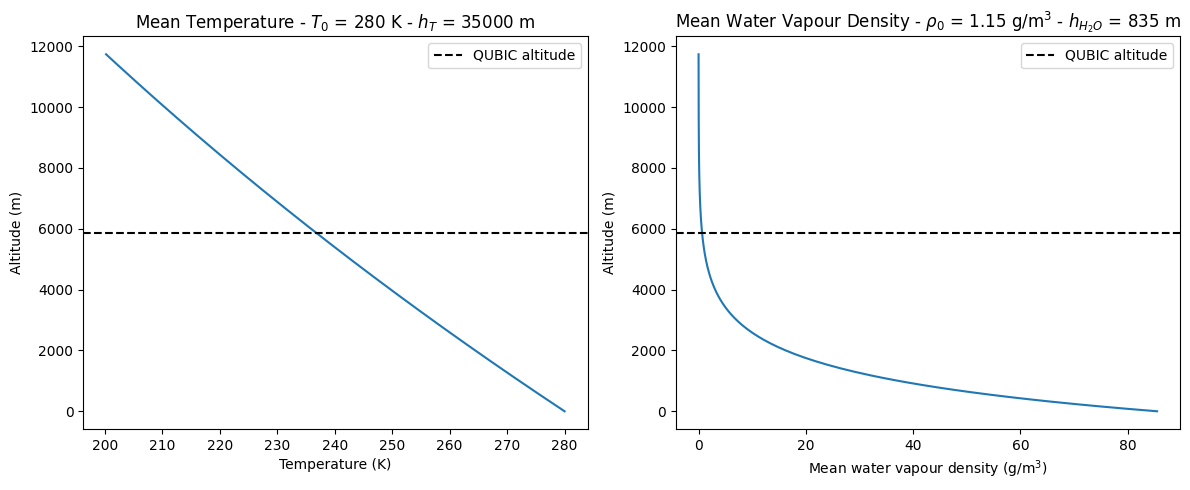

In [4]:
# Temperature and mean water vapor density profiles vs altitude
altitudes = np.linspace(0, 2 * atm.altitude[0], 300)  # m

temperature_profile = atm.get_temperature_atm(altitudes, params["temp_ground"], params["h_temp"])
water_vapor_profile = atm.get_mean_water_vapor_density(altitudes, params["rho_0"], params["h_h2o"])

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].plot(temperature_profile, altitudes)
axs[0].axhline(atm.altitude[0], color="k", ls="--", label="QUBIC altitude")
axs[0].set_xlabel("Temperature (K)")
axs[0].set_ylabel("Altitude (m)")
axs[0].set_title(
    rf"Mean Temperature - $T_{{0}}$ = {params['temp_ground']} K - $h_T$ = {params['h_temp']} m"
)
axs[0].legend()

axs[1].plot(water_vapor_profile, altitudes)
axs[1].axhline(atm.altitude[0], color="k", ls="--", label="QUBIC altitude")
axs[1].set_xlabel(r"Mean water vapour density (g/m$^3$)")
axs[1].set_ylabel("Altitude (m)")
axs[1].set_title(
    rf"Mean Water Vapour Density - $\rho_{{0}}$ = {params['rho_0']} g/m$^3$ - $h_{{H_2O}}$ = {params['h_h2o']} m"
)
axs[1].legend()

plt.tight_layout()
plt.show()

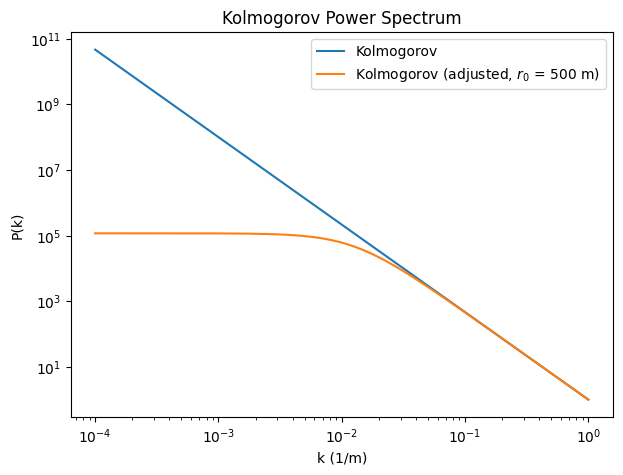

In [5]:
# Kolmogorov spectrum: adjusted (normalized to sigma_rho) vs unadjusted
k = np.logspace(-4, 0, 500)  # spatial frequencies, 1/m

P_unadjusted = atm.kolmogorov_spectrum(k, np.inf)
P_adjusted = atm.kolmogorov_spectrum(k, params["correlation_length"])

plt.figure(figsize=(7, 5))
plt.loglog(k, P_unadjusted, label="Kolmogorov")
plt.loglog(k, P_adjusted, label=r"Kolmogorov (adjusted, $r_0$ = {} m)".format(params["correlation_length"]))
plt.xlabel("k (1/m)")
plt.ylabel("P(k)")
plt.title("Kolmogorov Power Spectrum")
plt.legend()
plt.show()

QUBIC band 150 GHz: 131.25 - 168.75 GHz
QUBIC band 220 GHz: 192.50 - 247.50 GHz


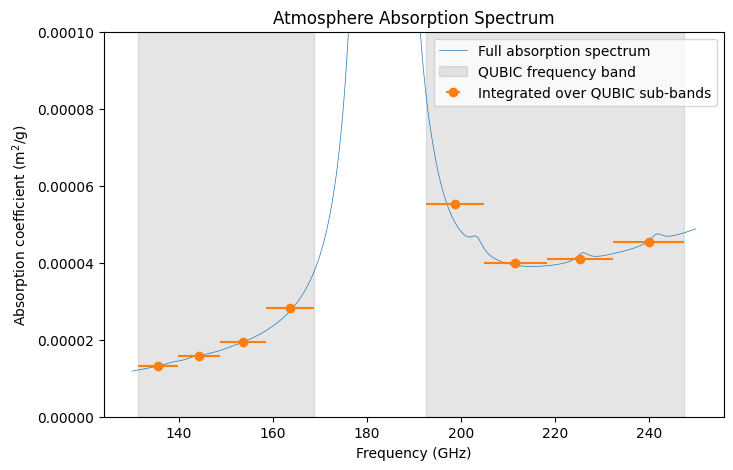

In [6]:
# Atmosphere absorption spectrum: full resolution and integrated over QUBIC sub-bands
relative_bandwidth = atm.qubic_dict["filter_relative_bandwidth"]
qubic_bands = [150, 220]

plt.figure(figsize=(8, 5))
plt.plot(atm.integration_frequencies, atm.abs_spectrum, lw=0.5, label="Full absorption spectrum")
plt.errorbar(
    atm.frequencies,
    atm.integrated_abs_spectrum,
    xerr=atm.bandwidths / 2,
    fmt="o",
    label="Integrated over QUBIC sub-bands",
)
for i, band in enumerate(qubic_bands):
    nu_min = band * (1 - relative_bandwidth / 2)
    nu_max = band * (1 + relative_bandwidth / 2)
    plt.axvspan(nu_min, nu_max, color="grey", alpha=0.2, label="QUBIC frequency band" if i == 0 else None)
    print("QUBIC band {} GHz: {:.2f} - {:.2f} GHz".format(band, nu_min, nu_max))
plt.xlabel("Frequency (GHz)")
plt.ylabel(r"Absorption coefficient (m$^2$/g)")
plt.ylim(0, 0.0001)
plt.title("Atmosphere Absorption Spectrum")
plt.legend()
plt.show()

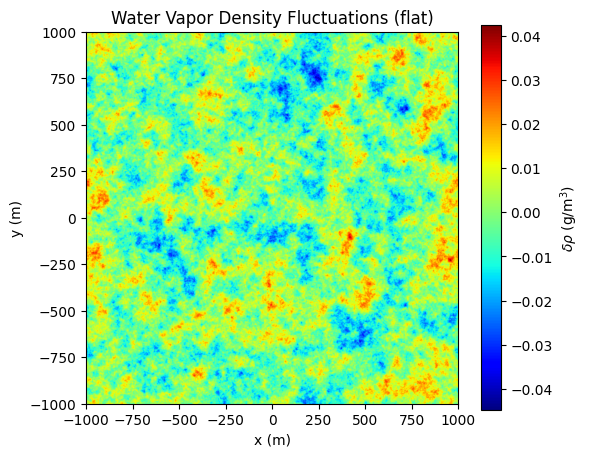

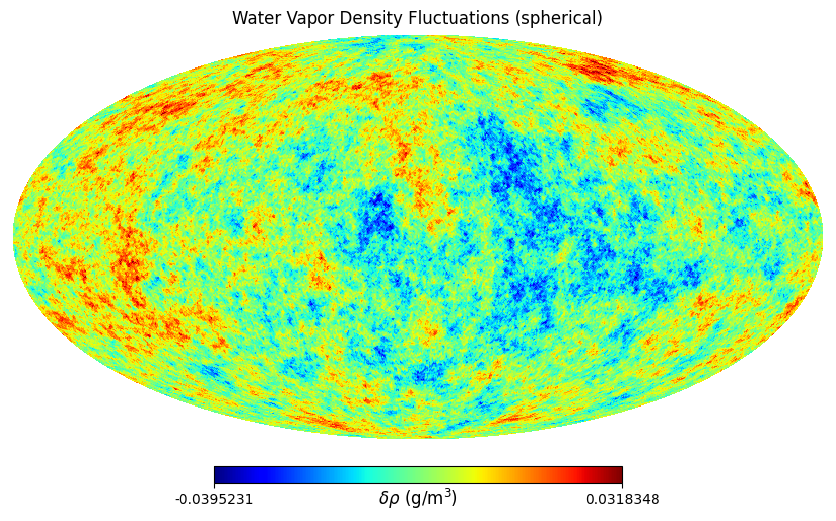

In [7]:
# Water vapor density fluctuation map: flat and spherical representations
# delta_rho_map is a fractional fluctuation (delta_rho / rho_bar, dimensionless) -- see get_temp_maps.
# We convert to an absolute density fluctuation (g/m^3) here purely for display.
rho_bar = atm.mean_water_vapor_density[0]

delta_rho_map_flat = atm.get_water_vapor_density_fluctuation_2d_map(flat=True) * rho_bar
delta_rho_map_hp = atm.get_water_vapor_density_fluctuation_2d_map(flat=False) * rho_bar

plt.figure(figsize=(6, 5))
plt.imshow(
    delta_rho_map_flat,
    extent=[-params["size_atm"], params["size_atm"], -params["size_atm"], params["size_atm"]],
    origin="lower",
    cmap="jet",
)
plt.colorbar(label=r"$\delta \rho$ (g/m$^3$)")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("Water Vapor Density Fluctuations (flat)")
plt.show()

hp.mollview(
    delta_rho_map_hp,
    title="Water Vapor Density Fluctuations (spherical)",
    unit=r"$\delta \rho$ (g/m$^3$)",
    cmap="jet",
)

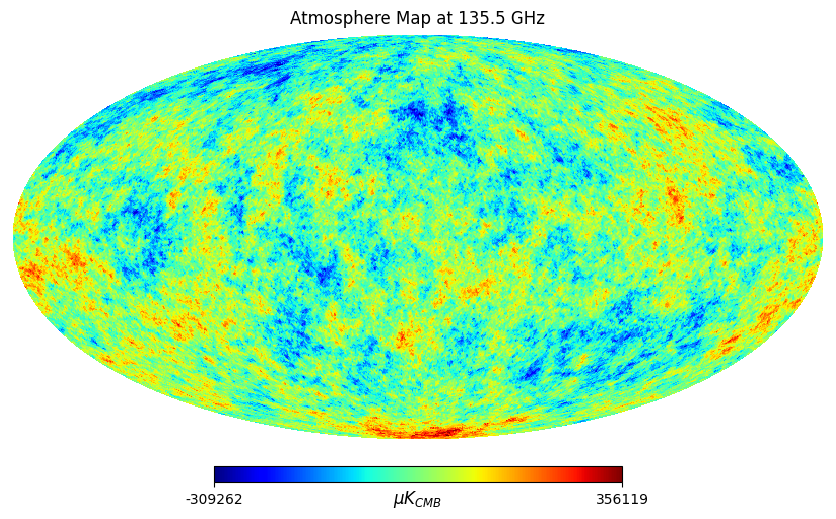

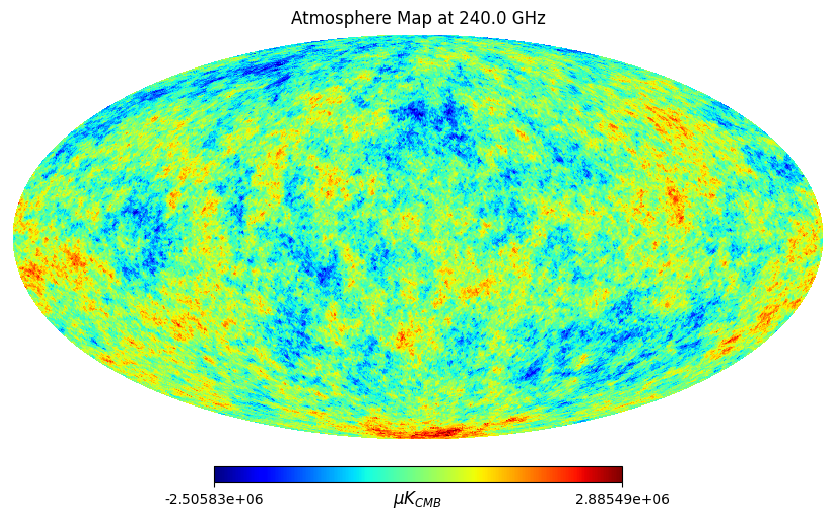

In [8]:
# Atmosphere temperature maps at the lowest and highest simulated frequencies
for idx in [0, -1]:
    title = f"Atmosphere Map at {atm.frequencies[idx]:.1f} GHz"
    if params["flat"]:
        plt.figure(figsize=(6, 5))
        plt.imshow(
            atm.atm_temp_maps[idx],
            extent=[-params["size_atm"], params["size_atm"], -params["size_atm"], params["size_atm"]],
            origin="lower",
            cmap="jet",
        )
        plt.colorbar(label=r"$\mu K_{CMB}$")
        plt.xlabel("x (m)")
        plt.ylabel("y (m)")
        plt.title(title)
        plt.show()
    else:
        hp.mollview(atm.atm_temp_maps[idx], title=title, unit=r"$\mu K_{CMB}$", cmap="jet")

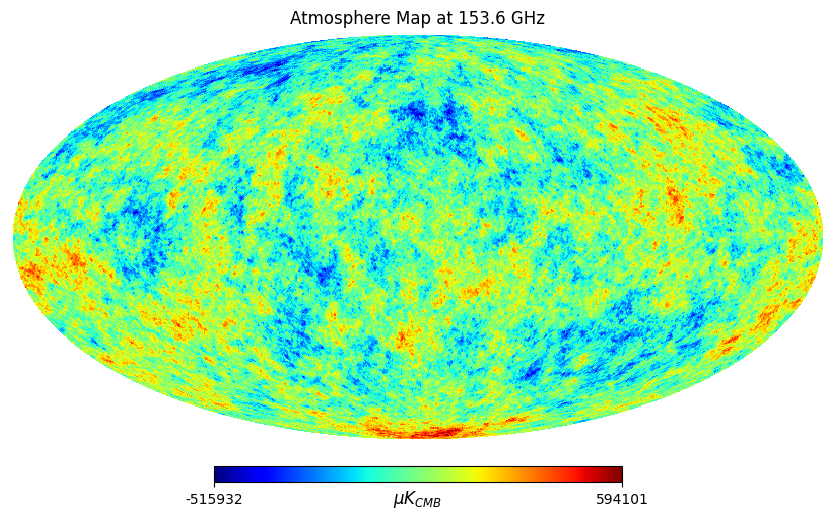

In [9]:
# Atmosphere temperature maps at 150 GHz
idx = np.argmin(np.abs(atm.frequencies - 150))
title = f"Atmosphere Map at {atm.frequencies[idx]:.1f} GHz"
if params["flat"]:
    plt.figure(figsize=(6, 5))
    plt.imshow(
        atm.atm_temp_maps[idx],
        extent=[-params["size_atm"], params["size_atm"], -params["size_atm"], params["size_atm"]],
        origin="lower",
        cmap="jet",
    )
    plt.colorbar(label=r"$\mu K_{CMB}$")
    plt.xlabel("x (m)")
    plt.ylabel("y (m)")
    plt.title(title)
    plt.show()
else:
    hp.mollview(atm.atm_temp_maps[idx], title=title, unit=r"$\mu K_{CMB}$", cmap="jet")